# Threshold exploration: saved crop predictions

Upload `hyperparameter_review.py` into the runtime's `roof_utils/` folder (or `/content`, where setup can place it). Restart the kernel and run the setup cells in order. Preserve the current utility versions; do not edit them while a training experiment is running. The project/data paths come from `.env`. No Drive mount is required.

The selected crop-enabled recipe is the reference. Threshold tuning and these comparisons are development analyses, not an independent final-test evaluation. Existing model checkpoints and original metrics are preserved.

This notebook needs the completed crop run's `experiment.json`, all five `fold_N/result.json` files, and per-image `.npz` predictions under `REPORTS_DIR`. If training happened on another Colab server, copy/download those reports and upload them here. The reference cell below reuses complete results or trains/resumes the crop reference when absent or incomplete. A GPU is needed only for training. Reusing complete reports requires no model checkpoint.

In [6]:
# Run this before importing project modules. Preserve Colab's working CUDA stack.
import sys, subprocess, importlib.util
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy>=1.24,<3', 'Pillow>=10,<13', 'matplotlib>=3.8,<4'])
if any(importlib.util.find_spec(name) is None for name in ('torch', 'torchvision')):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch==2.8.0', 'torchvision==0.23.0'])
# If pip requests a kernel restart, restart and rerun from here.


In [7]:
from pathlib import Path
import os
import sys
import importlib
import shutil

# Set this only if automatic discovery finds no project or multiple projects.
PROJECT_ROOT_OVERRIDE = os.environ.get('DIDA_PROJECT_ROOT', '')
if PROJECT_ROOT_OVERRIDE:
    candidates = [Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()]
else:
    candidates = [Path.cwd(), *Path.cwd().parents]
    if Path('/content').is_dir():
        candidates += [p.parent for p in Path('/content').rglob('pyproject.toml')]
roots = sorted({p.resolve() for p in candidates
                if (p / 'pyproject.toml').is_file() and (p / 'roof_utils').is_dir()})
if len(roots) != 1:
    raise RuntimeError(
        f'Found project roots: {roots}. Set PROJECT_ROOT_OVERRIDE to the runtime '
        'project directory. If none exist, upload the project/data to this Colab server.')
PROJECT_ROOT = roots[0]

# A file uploaded separately through VS Code may land at /content instead.
module_file = PROJECT_ROOT / 'roof_utils' / 'hyperparameter_review.py'
uploaded = Path('/content/hyperparameter_review.py')
if not module_file.is_file() and uploaded.is_file():
    if 'def threshold_sweep(' not in uploaded.read_text():
        raise ValueError('Uploaded hyperparameter_review.py does not contain the expected utility.')
    shutil.copy2(uploaded, module_file)
if not module_file.is_file():
    raise FileNotFoundError(f'Upload hyperparameter_review.py to {module_file}')

sys.path.insert(0, str(PROJECT_ROOT))
importlib.invalidate_caches()
import roof_utils
if Path(roof_utils.__file__).resolve().parent != PROJECT_ROOT / 'roof_utils':
    raise RuntimeError('A different roof_utils is cached. Restart the kernel and rerun in order.')
from roof_utils.config import load_paths

env_file = PROJECT_ROOT / '.env'
if not env_file.exists():
    env_file.write_text(
        'RAW_DATA_DIR=data\nPREPARED_DATA_DIR=data_preparation_outputs\n'
        'MODELS_DIR=models\nREPORTS_DIR=reports\n')
paths = load_paths(PROJECT_ROOT)
for directory in (paths.raw_data_dir, paths.prepared_data_dir):
    if not directory.is_dir():
        raise FileNotFoundError(f'{directory} is unavailable. Check runtime paths in {env_file}.')
print('Project:', PROJECT_ROOT)
print('Models:', paths.models_dir)
print('Reports:', paths.reports_dir)


Project: /content
Models: /content/models
Reports: /content/reports


In [8]:
from roof_utils.hyperparameter_review import (
    ensure_reference_run, threshold_sweep, plot_threshold_sweep, learning_rate_configs,
    compare_learning_rates, plot_learning_rate_comparison,
)
from roof_utils.cross_validation import CVConfig, run_cross_validation, plot_history, show_predictions
print('Reports directory:', paths.reports_dir)


Reports directory: /content/reports


Threshold   mean IoU   Dice      Precision Recall
0.200       0.7930     0.8820    0.8815    0.8919
0.225       0.7942     0.8827    0.8847    0.8900
0.250       0.7951     0.8832    0.8874    0.8883
0.275       0.7957     0.8835    0.8898    0.8866
0.300       0.7963     0.8838    0.8919    0.8852
0.325       0.7966     0.8840    0.8938    0.8836
0.350       0.7968     0.8841    0.8955    0.8822
0.375       0.7971     0.8842    0.8972    0.8808
0.400       0.7973     0.8844    0.8988    0.8794
0.425       0.7976     0.8845    0.9005    0.8781
0.450       0.7979     0.8847    0.9021    0.8768
0.475       0.7982     0.8848    0.9037    0.8756
0.500       0.7981     0.8847    0.9050    0.8743
0.525       0.7982     0.8848    0.9065    0.8729
0.550       0.7983     0.8848    0.9078    0.8717
0.575       0.7984     0.8848    0.9096    0.8701
0.600       0.7981     0.8845    0.9111    0.8681
0.625       0.6248     0.6957    0.7227    0.6771
0.650       0.6246     0.6955    0.7238    0.6758


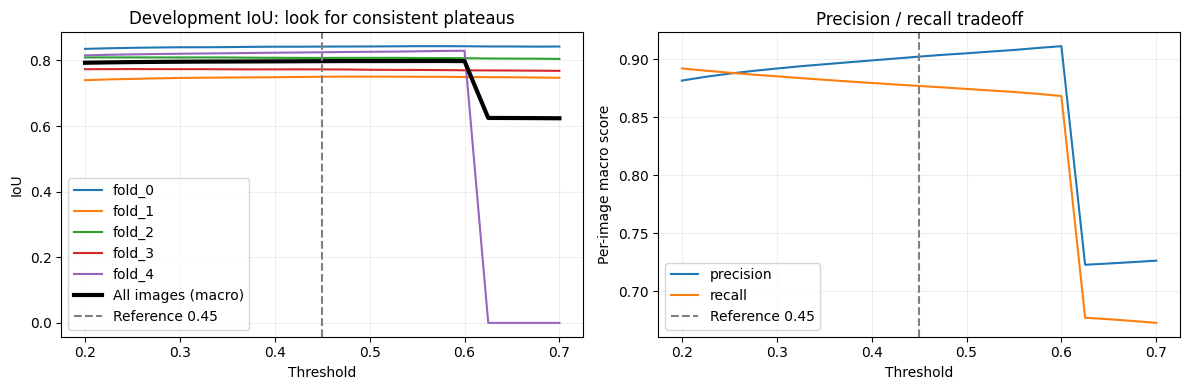

In [11]:
CROP_RUN = "crop_lr_3x_500"
THRESHOLDS = [round(0.20 + i * 0.025, 3) for i in range(21)]
REFERENCE_THRESHOLD = 0.45

sweep = threshold_sweep(paths, CROP_RUN, thresholds=THRESHOLDS)
plot_threshold_sweep(sweep, reference_threshold=REFERENCE_THRESHOLD)